In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# feature space 1
importing feature set 1 (used in study 6 and 8) and their locations in embedding space  
exports a df `features_dataframe.pkl` where each row is a feature and cols hold info about them (location in embedding space, whether they were used in train or test, etc.)

In [2]:
with open('set1_feature_embeddings_384d.pkl', 'rb') as f:
    set1_feature_embeddings_384d = pkl.load(f)

with open('set1_feature_embeddings_2d.pkl', 'rb') as f:
    set1_feature_embeddings_2d = pkl.load(f)

In [3]:
set1_training_features_by_type = {
    "physical": [
        "have freckles on their feet",
    ],
    "appearance": [
        "have stripes in their hair",
        "draw stars on their knees",
    ],
    "abilities": [
        "can bounce a ball on their heads",
        "can flip in the air",
    ],
    "hobbies_behaviors": [
        "climb tall fences",
        "flap their arms when they are happy",
        "hop over puddles",
        "are scared of ladybugs",
        "chase shadows",
    ],
    "habitat": [
        "sleep in tall trees",
    ],
    "diet_preferences": [
        "love to eat flowers",
        "like to sing",
        "really don't like walking in the mud",
        "really don't like ice cream",
    ],
    "beliefs_culture": [
        "babies are wrapped in orange blankets",
    ],
}


set1_test_features_by_type = {
    "hobbies_behaviors": [
        "live in caves",
        "ride lions",
        "farm potatoes",
        "play banjos",
        "look to their left when spoken to",
        "clap three times before entering a room",
        "smile when they are sad",
        "chug maple syrup",
        "yell at stray cats",
        "go to the opera",
        "sing beautiful songs",
        "scream out windows",
        "smell garbage for fun",
        "wash their clothes in ponds",
        "paint their hands yellow"
    ],
    "beliefs_culture": [
        "dance around a fire on their 10th birthday",
    ]
}

# feature space 2
importing feature set 2 (used in study 9), their locations in embedding space, and info about their categories (phys, diet, personality)  
exports a df `features_dataframe.pkl` where each row is a feature and cols hold info about them (location in embedding space, category of feature, whether they were used in the heterogenous condition)

In [8]:
with open('set2_all_features.pkl', 'rb') as f:
    set2_all_features = pkl.load(f)

with open('set2_feature_embeddings_384d.pkl', 'rb') as f:
    feature_embeddings_384d = pkl.load(f)

with open('set2_feature_embeddings_2d.pkl', 'rb') as f:
    feature_embeddings_2d = pkl.load(f)

In [5]:
feature_embeddings_384d

array([[-0.02164809,  0.0500215 , -0.0274377 , ...,  0.01019078,
        -0.0006189 ,  0.0277209 ],
       [-0.02201648, -0.02949436, -0.04232144, ...,  0.03735314,
         0.04180059, -0.01106481],
       [-0.06632441,  0.06069598,  0.0322907 , ...,  0.00062849,
         0.06248857, -0.00429389],
       ...,
       [-0.0313298 ,  0.08126681, -0.00275643, ..., -0.03143487,
        -0.03429929, -0.03467501],
       [-0.01642577,  0.0170465 ,  0.03193023, ...,  0.02209746,
         0.03177208, -0.00158381],
       [-0.06142882,  0.01765107, -0.00656863, ...,  0.0773751 ,
         0.01097291, -0.00092884]], shape=(60, 384), dtype=float32)

In [6]:
feature_embeddings_2d

{'have wide feet': (np.float32(-0.31923786), np.float32(0.11424483)),
 'have a loud voice': (np.float32(-0.058054764), np.float32(-0.13941406)),
 'have freckles on their feet': (np.float32(-0.41682476),
  np.float32(0.19605576)),
 'can touch their toes': (np.float32(-0.33474883), np.float32(0.1835125)),
 'have stripes in their hair': (np.float32(-0.2763301),
  np.float32(0.07536636)),
 'have tattoos': (np.float32(-0.22142641), np.float32(-0.0155774625)),
 'can see really far': (np.float32(-0.14921238), np.float32(-0.07607446)),
 'tan easily': (np.float32(-0.10224209), np.float32(0.05056657)),
 'have a flat belly button': (np.float32(-0.19377226), np.float32(0.17659602)),
 'have bony elbows': (np.float32(-0.29524744), np.float32(0.2858811)),
 'paint their toenails': (np.float32(-0.2690363), np.float32(0.13857538)),
 'draw circles on their knees': (np.float32(-0.35242864),
  np.float32(0.12959327)),
 'have short nails': (np.float32(-0.29960376), np.float32(0.13679811)),
 'wear tall socks

In [9]:
# Create an ordered list of features for consistent indexing
features_list = sorted(set2_all_features)  # alphabetical order
print(f"Total features: {len(features_list)}")
print(f"Embeddings shape: {feature_embeddings_384d.shape}")
print(f"2D positions: {len(feature_embeddings_2d)}")

# Verify all features have 2D coordinates
missing_in_2d = set(features_list) - set(feature_embeddings_2d.keys())
if missing_in_2d:
    print(f"\nFeatures missing 2D coordinates: {missing_in_2d}")
else:
    print("\n✓ All features have 2D coordinates!")

Total features: 60
Embeddings shape: (60, 384)
2D positions: 60

✓ All features have 2D coordinates!


In [10]:
# Helper functions to connect the data structures

def get_feature_embedding_384d(feature_name, feature_list=features_list):
    """Get 384d embedding for a feature by name"""
    idx = feature_list.index(feature_name)
    return feature_embeddings_384d[idx]

def get_feature_position_2d(feature_name):
    """Get 2D position for a feature by name"""
    return feature_embeddings_2d[feature_name]

# Example: Get data for a specific feature
example_feature = "like to eat broccoli"
emb_384d = get_feature_embedding_384d(example_feature)
pos_2d = get_feature_position_2d(example_feature)

print(f"Feature: '{example_feature}'")
print(f"384D embedding shape: {emb_384d.shape}")
print(f"384D embedding (first 5): {emb_384d[:5]}")
print(f"2D position: {pos_2d}")

Feature: 'like to eat broccoli'
384D embedding shape: (384,)
384D embedding (first 5): [ 0.00712189  0.0203646  -0.03444236  0.04099965 -0.02280279]
2D position: (np.float32(0.33064175), np.float32(0.15156229))


In [11]:
feature_data = {}
for i, feature in enumerate(features_list):
    feature_data[feature] = {
        'embedding_384d': feature_embeddings_384d[i],
        'position_2d': feature_embeddings_2d[feature],
        'x': feature_embeddings_2d[feature][0],
        'y': feature_embeddings_2d[feature][1]
    }

# Example usage
print("Example - accessing 'are brave':")
print(f"  2D position: ({feature_data['are brave']['x']:.3f}, {feature_data['are brave']['y']:.3f})")
print(f"  384D embedding: {feature_data['are brave']['embedding_384d'][:3]}...")

Example - accessing 'are brave':
  2D position: (-0.100, -0.270)
  384D embedding: [-0.02201648 -0.02949436 -0.04232144]...


In [12]:
# Define feature categories
training_features_by_type = {
    "physical": (
        "have wide feet",
        "have a loud voice",
        "have freckles on their feet",
        "can touch their toes",
        "have stripes in their hair",
        "have tattoos",
        "can see really far",
        "tan easily",
        "have a flat belly button",
        "have bony elbows",
        "paint their toenails",
        "draw circles on their knees",
        "have short nails",
        "wear tall socks",
        "have orange earwax",
    ),
    "diet_preferences": (
        "eat rice",
        "eat nuts",
        "eat meat",
        "eat cheese",
        "drink milk",
        "like to eat sweets",
        "like to eat broccoli",
        "like to eat herbs",
        "make bread",
        "farm potatoes",
        "like to drink maple syrup",
        "like to drink tea",
        "like to drink fizzy water",
        "really don't like ice cream",
        "really don't like soup",
    ),
    "personality_behaviors": (
        "are friendly",
        "are curious",
        "are silly",
        "are smart",
        "are thoughtful",
        "are forgetful",
        "are angry",
        "take care of others",
        "live with their families",
        "can do cartwheels",
        "teach children",
        "like to ride bikes",
        "give good gifts",
        "tell bad jokes",
        "are brave",
    ),
}

test_features_by_type = {
    "physical": (
        "snore when they sleep", 
        "can wiggle their ears",
        "can roll their tongue", 
        "have cold hands and feet",
        "can snap with their toes",
    ),
    "diet_preferences": (
        "can eat spicy food",
        "eat breakfast very late",
        "like juice with pulp",
        "eat five meals a day",
        "put pepper on all their foods",
    ),
    "personality_behaviors": (
        "like to dance",
        "like to read books",
        "like to collect rocks",
        "cry easily",
        "like to give high-fives",
    )
}

heterogenous_training_features = (
    "have freckles on their feet",
    "have a flat belly button",
    "can touch their toes",
    "tan easily",
    "have orange earwax",
    "eat rice",
    "like to eat broccoli",
    "like to eat herbs",
    "make bread",
    "really don't like soup",
    "are friendly",
    "are angry",
    "are brave",
    "like to ride bikes",
    "tell bad jokes"
)

In [15]:
# Create lists to store feature metadata
feature_names = []
categories = []
split_types = []  # train, test, or heterogenous_train
is_heterogenous = []

# Helper function to get category for a feature
def get_category(feature_name):
    for category, features in training_features_by_type.items():
        if feature_name in features:
            return category
    for category, features in test_features_by_type.items():
        if feature_name in features:
            return category
    return None

# Helper function to get split type
def get_split_type(feature_name):
    # Check if in heterogenous training set
    if feature_name in heterogenous_training_features:
        return "train" # used to be "heterogenous_train"
    
    # Check if in training set
    for features in training_features_by_type.values():
        if feature_name in features:
            return "train"
    
    # Check if in test set
    for features in test_features_by_type.values():
        if feature_name in features:
            return "test"
    
    return None

# Build metadata for each feature
for feature in features_list:
    feature_names.append(feature)
    categories.append(get_category(feature))
    split_types.append(get_split_type(feature))
    is_heterogenous.append(feature in heterogenous_training_features)

# Create dataframe with all information
df = pd.DataFrame({
    'feature': feature_names,
    'category': categories,
    'split': split_types,
    'in_heterogenous': is_heterogenous,
    'x_2d': [feature_embeddings_2d[f][0] for f in feature_names],
    'y_2d': [feature_embeddings_2d[f][1] for f in feature_names],
})

# Add the 384d embeddings as a separate column (as arrays)
df['embedding_384d'] = [feature_embeddings_384d[i] for i in range(len(feature_names))]

print(f"DataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
df

DataFrame shape: (60, 7)

First few rows:


,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
0,are angry,personality_behaviors,train,True,-0.073863,-0.238874,"[-0.02164809, 0.050021496, -0.027437702, 0.012..."
1,are brave,personality_behaviors,train,True,-0.100276,-0.269504,"[-0.022016477, -0.029494364, -0.042321444, 0.0..."
2,are curious,personality_behaviors,train,False,-0.085597,-0.184920,"[-0.06632441, 0.060695983, 0.0322907, 0.080090..."
3,are forgetful,personality_behaviors,train,False,-0.047072,-0.263889,"[-0.047100894, -0.008117868, -0.013956301, 0.0..."
4,are friendly,personality_behaviors,train,True,0.030569,-0.241963,"[-0.03688672, 0.047983356, -0.044930663, 0.021..."
5,are silly,personality_behaviors,train,False,-0.033539,-0.197804,"[0.0026597937, 0.053914584, -0.04729352, 0.079..."
6,are smart,personality_behaviors,train,False,-0.048692,-0.259000,"[0.027360268, 0.037556354, -0.0355133, 0.00958..."
7,are thoughtful,personality_behaviors,train,False,-0.002703,-0.383120,"[-0.005612112, 0.042879116, 0.0057593207, 0.12..."
8,can do cartwheels,personality_behaviors,train,False,-0.205188,0.003862,"[-0.023610912, 0.011955042, -0.08422319, 0.061..."
9,can eat spicy food,diet_preferences,test,False,0.301567,0.192541,"[-0.007894761, 0.031925637, -0.027855761, 0.04..."


In [16]:
df

,feature,category,split,in_heterogenous,x_2d,y_2d,embedding_384d
0,are angry,personality_behaviors,train,True,-0.073863,-0.238874,"[-0.02164809, 0.050021496, -0.027437702, 0.012..."
1,are brave,personality_behaviors,train,True,-0.100276,-0.269504,"[-0.022016477, -0.029494364, -0.042321444, 0.0..."
2,are curious,personality_behaviors,train,False,-0.085597,-0.184920,"[-0.06632441, 0.060695983, 0.0322907, 0.080090..."
3,are forgetful,personality_behaviors,train,False,-0.047072,-0.263889,"[-0.047100894, -0.008117868, -0.013956301, 0.0..."
4,are friendly,personality_behaviors,train,True,0.030569,-0.241963,"[-0.03688672, 0.047983356, -0.044930663, 0.021..."
5,are silly,personality_behaviors,train,False,-0.033539,-0.197804,"[0.0026597937, 0.053914584, -0.04729352, 0.079..."
6,are smart,personality_behaviors,train,False,-0.048692,-0.259000,"[0.027360268, 0.037556354, -0.0355133, 0.00958..."
7,are thoughtful,personality_behaviors,train,False,-0.002703,-0.383120,"[-0.005612112, 0.042879116, 0.0057593207, 0.12..."
8,can do cartwheels,personality_behaviors,train,False,-0.205188,0.003862,"[-0.023610912, 0.011955042, -0.08422319, 0.061..."
9,can eat spicy food,diet_preferences,test,False,0.301567,0.192541,"[-0.007894761, 0.031925637, -0.027855761, 0.04..."


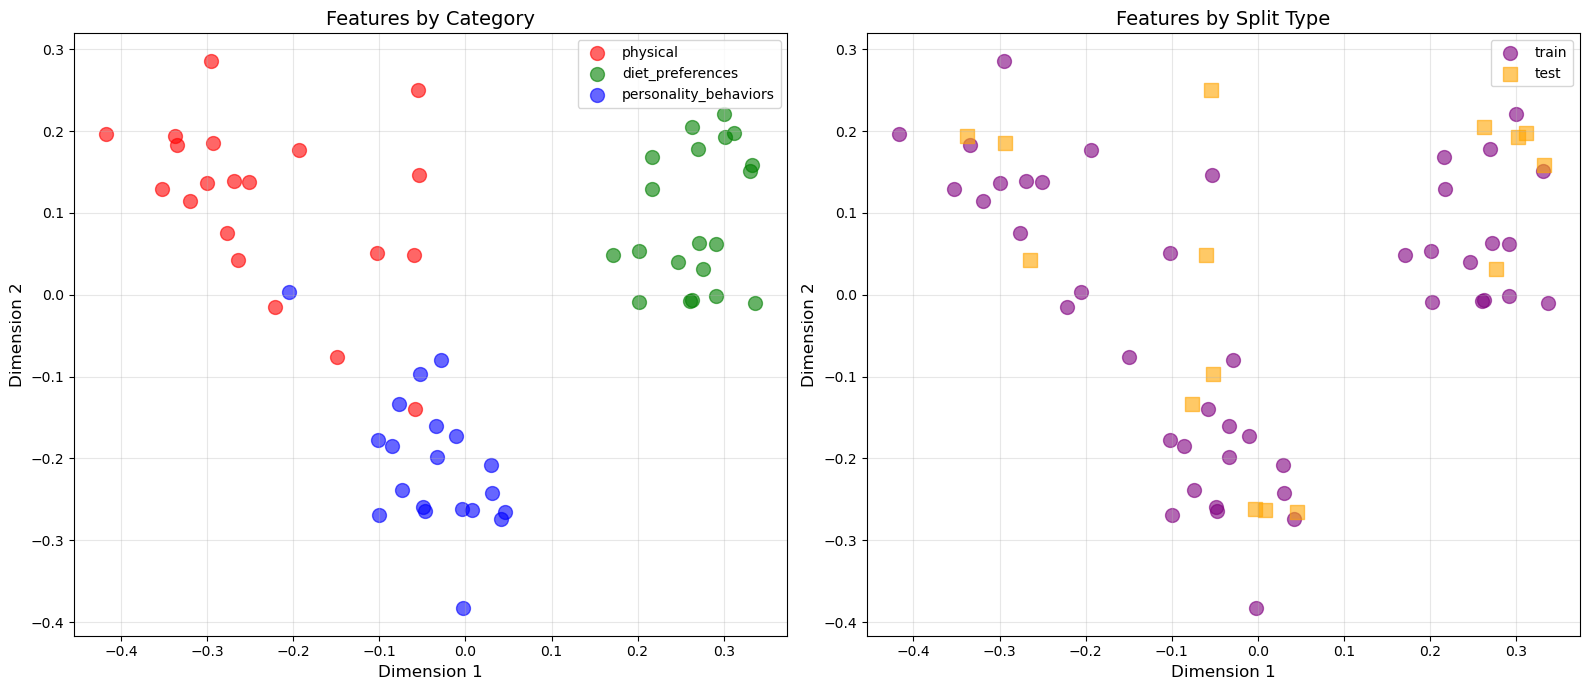

In [17]:
# Visualize features colored by category
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Colored by category
category_colors = {'physical': 'red', 'diet_preferences': 'green', 'personality_behaviors': 'blue'}
for category, color in category_colors.items():
    mask = df['category'] == category
    axes[0].scatter(df[mask]['x_2d'], df[mask]['y_2d'], 
                   c=color, label=category, alpha=0.6, s=100)

axes[0].set_xlabel('Dimension 1', fontsize=12)
axes[0].set_ylabel('Dimension 2', fontsize=12)
axes[0].set_title('Features by Category', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Colored by split type
split_colors = {'train': 'purple', 'test': 'orange'}
split_markers = {'train': 'o', 'test': 's', 'heterogenous_train': '^'}
for split, color in split_colors.items():
    mask = df['split'] == split
    marker = split_markers[split]
    axes[1].scatter(df[mask]['x_2d'], df[mask]['y_2d'], 
                   c=color, label=split, alpha=0.6, s=100, marker=marker)

axes[1].set_xlabel('Dimension 1', fontsize=12)
axes[1].set_ylabel('Dimension 2', fontsize=12)
axes[1].set_title('Features by Split Type', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Example queries on the dataframe

# 1. Get all heterogenous training features
print("=== Heterogenous Training Features ===")
print(df[df['in_heterogenous'] == True]['feature'].tolist())

# 2. Get all physical features in test set
print("\n=== Physical Features in Test Set ===")
print(df[(df['category'] == 'physical') & (df['split'] == 'test')]['feature'].tolist())

# 3. Get a specific feature's info
print("\n=== Info for 'like to eat broccoli' ===")
feature_info = df[df['feature'] == 'like to eat broccoli'].iloc[0]
print(f"Category: {feature_info['category']}")
print(f"Split: {feature_info['split']}")
print(f"2D position: ({feature_info['x_2d']:.3f}, {feature_info['y_2d']:.3f})")
print(f"384D embedding shape: {feature_info['embedding_384d'].shape}")

# 4. Count features by category and split
print("\n=== Crosstab: Category × Split ===")
print(pd.crosstab(df['category'], df['split']))

=== Heterogenous Training Features ===
['are angry', 'are brave', 'are friendly', 'can touch their toes', 'eat rice', 'have a flat belly button', 'have freckles on their feet', 'have orange earwax', 'like to eat broccoli', 'like to eat herbs', 'like to ride bikes', 'make bread', "really don't like soup", 'tan easily', 'tell bad jokes']

=== Physical Features in Test Set ===
['can roll their tongue', 'can snap with their toes', 'can wiggle their ears', 'have cold hands and feet', 'snore when they sleep']

=== Info for 'like to eat broccoli' ===
Category: diet_preferences
Split: train
2D position: (0.331, 0.152)
384D embedding shape: (384,)

=== Crosstab: Category × Split ===
split                  test  train
category                          
diet_preferences          5     15
personality_behaviors     5     15
physical                  5     15


In [19]:
# Optional: Save the dataframe (uncomment to use)
df.to_pickle('set2_features_dataframe.pkl')
print("Saved to set2_features_dataframe.pkl")

# Or save as CSV (without 384d embeddings, since they're arrays)
# df_for_csv = df.drop(columns=['embedding_384d'])
# df_for_csv.to_csv('features_metadata.csv', index=False)
# print("Saved metadata to features_metadata.csv")

Saved to set2_features_dataframe.pkl
